In [2]:
import tensorflow as tf
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt 

In [3]:
#params

image_size = 256
batch_size = 32
channel = 3
epochs = 2

In [4]:
#creating data set 
dataset = tf.keras.utils.image_dataset_from_directory(
    "FinalDataSet",
    shuffle=True,
    image_size=(image_size,image_size),
    batch_size=batch_size
)

Found 5239 files belonging to 20 classes.


In [4]:
class_names = dataset.class_names

In [5]:
class_names 

['burger',
 'butter_naan',
 'chai',
 'chapati',
 'chole_bhature',
 'dal_makhani',
 'dhokla',
 'fried_rice',
 'idli',
 'jalebi',
 'kaathi_rolls',
 'kadai_paneer',
 'kulfi',
 'masala_dosa',
 'momos',
 'paani_puri',
 'pakode',
 'pav_bhaji',
 'pizza',
 'samosa']

NameError: name 'class_names' is not defined

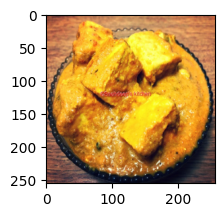

In [5]:
plt.figure(figsize = (10,10))
for image_batch,label_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3,4,i+1) 
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")

In [6]:
train_size = 0.8
len(dataset) * train_size

131.20000000000002

In [7]:
train_ds = dataset.take(131)

In [8]:
bal_ds=dataset.skip(131)

In [9]:
val_size =.1


In [10]:
len(dataset) * val_size

16.400000000000002

In [11]:
val_ds = bal_ds.take(16)
test_ds = bal_ds.skip(16)

In [12]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + test_split + val_split) == 1
    
    ds_size = len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    
    train_ds = ds.take(train_size)    
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds, test_ds

In [13]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [14]:
len(train_ds)

131

In [15]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [18]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(image_size, image_size),
    layers.Rescaling(1./255)
])

In [19]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])

In [21]:
#cnn model creation

model = models.Sequential([
    
    #conv layer 1
   layers.Conv2D(32, kernel_size = (3,3), activation ='relu', input_shape = (256,256,3)),
   layers.MaxPooling2D((2,2)),
    
    #conv layer 2
   layers.Conv2D(64, kernel_size = (3,3), activation ='relu'),
   layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    layers.Dense(64 , activation='relu'),   
    layers.Dense( 20, activation='relu')
])
model.build(input_shape=(256,256,3))

ValueError: Sequential model 'sequential_3' has already been configured to use input shape (None, 256, 256, 3). You cannot build it with input_shape (256, 256, 3)

In [22]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 246016)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │    15,745,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │         1,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,765,780 (60.14 MB)

 Trainable params: 15,765,780 (60.14 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), metrics=['accuracy'])

In [24]:
history = model.fit(
    train_ds,
    batch_size = batch_size,
    validation_data = val_ds,
    verbose = 1,
    epochs = 20
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 75s 464ms/step - accuracy: 0.0576 - loss: 12.8030 - val_accuracy: 0.0586 - val_loss: 13.0035
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 55s 417ms/step - accuracy: 0.0568 - loss: 12.8678 - val_accuracy: 0.0586 - val_loss: 13.0035
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 55s 421ms/step - accuracy: 0.0553 - loss: 13.0026 - val_accuracy: 0.0586 - val_loss: 13.0035
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 54s 413ms/step - accuracy: 0.0557 - loss: 13.1064 - val_accuracy: 0.0586 - val_loss: 13.0035
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 54s 412ms/step - accuracy: 0.0490 - loss: 13.0904 - val_accuracy: 0.0586 - val_loss: 13.0035
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 56s 425ms/step - accuracy: 0.0630 - loss: 13.0348 - val_accuracy: 0.0586 - val_loss: 13.0035
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 55s 423ms/step - accuracy: 0.0643 - loss: 12.7884 - val_accuracy: 0.0586 - val_loss: 13.0035
Epoch 8/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 57s 432ms/step - accuracy: 0.

first image to predict


NameError: name 'class_names' is not defined

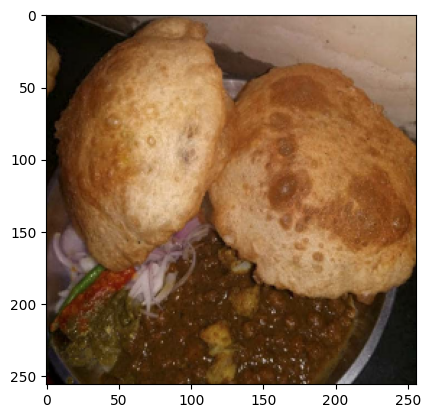

In [26]:
import numpy as np

for images_batch, labels_batch in test_ds.take(1):
    
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:", class_names[first_label])
    
    batch_prediction = model.predict(images_batch)
    print("predicted label:", class_names[np.argmax(batch_prediction[0])])

In [27]:
#saving model

model.save("rawModelv1.h5")